<h3><b>Implementation of Deep Feed Forward Neural Network (DFFNN) with Mini-Batch/Stochastic Gradient Descent Algorithm in combination with Momentum Algorithm</b></h3>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn.datasets
import scipy.io
import time
import h5py

In [3]:
def layer_sizes(X, Y, num_hidden_units):

    num_input_units = [X.shape[0]]
    num_hidden_units = list(num_hidden_units)
    num_output_units = [Y.shape[0]]
    layer_units = list(num_input_units + num_hidden_units + num_output_units)

    return layer_units

In [4]:
def initialize_parameters(layer_units):

    parameters = {}
    L = len(layer_units)

    for l in range(1, L):
        parameters[f"W{l}"] = np.random.randn(layer_units[l], layer_units[l-1]) * np.sqrt(2 / layer_units[l - 1])
        parameters[f"b{l}"] = np.zeros((layer_units[l], 1))

    return parameters

In [39]:
def initialize_momentum(parameters):

    momentum = {}
    L = len(parameters) // 2

    for l in range(1, L + 1):

        momentum[f"vdW{l}"] = np.zeros(parameters[f"W{l}"].shape)
        momentum[f"vdb{l}"] = np.zeros(parameters[f"b{l}"].shape)
        
    return momentum   

In [6]:
def relu(Z):
    A = np.maximum(0, Z)
    cache = Z

    return A, cache

In [7]:
def sigmoid(Z):

    A = 1 / (1 + np.exp(-Z))
    cache = Z

    return A, cache

In [8]:
def forward_propagation(X, parameters):

    caches = []
    A = X
    L = len(parameters) // 2

    for l in range(1, L):
        A_prev = A
        W = parameters[f"W{l}"]
        b = parameters[f"b{l}"]

        linear_cache = (A_prev, W, b)
        Z = np.dot(W, A_prev) + b
        A, activation_cache = relu(Z)
        caches.append((linear_cache, activation_cache))

    A_prev = A
    W = parameters[f"W{L}"]
    b = parameters[f"b{L}"]
    linear_cache = (A_prev, W, b)

    Z = np.dot(W, A_prev) + b
    A, activation_cache = sigmoid(Z)

    caches.append((linear_cache, activation_cache))

    return A, caches

In [10]:
def compute_cost(A, Y):
    
    """
    This is used with mini-batches, 
    so we'll first accumulate costs over an entire epoch 
    and then divide by the m training examples
    """
    
    logprobs = np.multiply(-np.log(A + 1e-15), Y) + np.multiply(-np.log(1 - A + 1e-15), 1 - Y)
    cost_total =  np.sum(logprobs)
    
    return cost_total

In [11]:
def backward_sigmoid(dA, Z):

    A = 1 / (1 + np.exp(-Z))
    dZ = np.multiply(np.multiply(dA, A), 1 - A)

    return dZ

In [12]:
def backward_relu(dA, cache):

    dZ = np.array(dA, copy=True)
    dZ[cache <= 0] = 0

    return dZ

In [13]:
def backward_propagation(AL, Y, caches):
    
    Y = Y.reshape(AL.shape)
    L = len(caches)
    gradients = {}

    dAL = - (np.divide(Y, AL + 1e-15) - np.divide(1 - Y, 1 - AL + 1e-15))

    (linear_cache, activation_cache) = caches[-1]
    (A_prev, W, b) = linear_cache
    m = A_prev.shape[1]

    dZ = backward_sigmoid(dAL, activation_cache)
    gradients[f"dA{L-1}"] = np.dot(W.T, dZ)
    gradients[f"dW{L}"] = 1 / m * np.dot(dZ, A_prev.T)
    gradients[f"db{L}"] = 1 / m * np.sum(dZ, axis=1, keepdims=True)

    for l in reversed(range(L - 1)):

        (linear_cache, activation_cache) = caches[l]
        (A_prev, W, b) = linear_cache
        m = A_prev.shape[1]

        dZ = backward_relu(gradients[f"dA{l+1}"], activation_cache)
        gradients[f"dA{l}"] = np.dot(W.T, dZ)
        gradients[f"dW{l+1}"] = 1 / m * np.dot(dZ, A_prev.T)
        gradients[f"db{l+1}"] = 1 / m * np.sum(dZ, axis=1, keepdims=True)

    return gradients

In [40]:
def compute_momentum(parameters, gradients, momentum, beta):
    
    L = len(parameters) // 2

    for l in range(1, L + 1):
        
        momentum[f"vdW{l}"] = (beta * momentum[f"vdW{l}"]) + ((1 - beta) * gradients[f"dW{l}"])
        momentum[f"vdb{l}"] = (beta * momentum[f"vdb{l}"]) + ((1 - beta) * gradients[f"db{l}"])
    
    return momentum    

In [41]:
def update_parameters(parameters, momentum, learning_rate):

    L = len(parameters) // 2

    for l in range(1, L + 1):
        
        parameters[f"W{l}"] -= learning_rate * momentum[f"vdW{l}"]
        parameters[f"b{l}"] -= learning_rate * momentum[f"vdb{l}"]

    return parameters

In [16]:
def predict(X, parameters):

    A, _ = forward_propagation(X, parameters)

    A = (A > 0.5).astype(int)

    return A

In [17]:
def accuracy(A, Y):
    
    accuracy = np.sum((A == Y) / Y.shape[1])

    return accuracy

In [18]:
def random_mini_batches(X, Y, mini_batch_size, seed):

    np.random.seed(seed) 
    m = X.shape[1]  
    mini_batches = []
        
    
    permutation = np.random.permutation(m)
    shuffled_X = X[:, permutation]
    shuffled_Y = Y[:, permutation].reshape((1, m))
    
    # Step 2: Partition the shuffled data into mini-batches
    num_complete_minibatches = m // mini_batch_size  
    
    for k in range(num_complete_minibatches):
        start_idx = k * mini_batch_size
        end_idx = (k + 1) * mini_batch_size
        mini_batch_X = shuffled_X[:, start_idx:end_idx]
        mini_batch_Y = shuffled_Y[:, start_idx:end_idx]
        mini_batches.append((mini_batch_X, mini_batch_Y))
    
    # Handling the end case (last mini-batch may have fewer examples)
    if m % mini_batch_size != 0:
        start_idx = num_complete_minibatches * mini_batch_size
        mini_batch_X = shuffled_X[:, start_idx:]
        mini_batch_Y = shuffled_Y[:, start_idx:]
        mini_batches.append((mini_batch_X, mini_batch_Y))
    
    return mini_batches

In [29]:
def train(X_train, Y_train, X_test, Y_test, num_hidden_units, num_epochs=1000, learning_rate=1e-3, beta=0.9, mini_batch_size=64, epsilon=100, seed=1):
    
    train_time = 0
    cost_ = []
    num_layer_units = layer_sizes(X_train, Y_train, num_hidden_units)
    parameters = initialize_parameters(num_layer_units)
    momentum = initialize_momentum(parameters)
    m = X_train.shape[1]
    
    for i in range(num_epochs):
        
        tic = time.time()
        seed = seed + 1
        minibatches = random_mini_batches(X_train, Y_train, mini_batch_size, seed)
        cost_total = 0
        
        for minibatch in minibatches:

            (X_minibatch, Y_minibatch) = minibatch 
            A_minibatch, minibatch_caches = forward_propagation(X_minibatch, parameters)
            cost_total += compute_cost(A_minibatch, Y_minibatch)
            gradients = backward_propagation(A_minibatch, Y_minibatch, minibatch_caches)
            momentum = compute_momentum(parameters, gradients, momentum, beta)
            parameters = update_parameters(parameters, momentum, learning_rate)
        
        toc = time.time()
        train_time += toc - tic
        cost_.append(cost_total / m)
        
        if i % epsilon == 0:
            print(f"Epoch: {i}; Cost: {cost_total / m}")

    train_accuracy = accuracy(predict(X_train, parameters), Y_train)
    test_accuracy = accuracy(predict(X_test, parameters), Y_test)
    
    print(f"Train Accuracy: {train_accuracy}")
    print(f"Test Accuracy: {test_accuracy}")
    print(f"Train Duration: {train_time}")

    plt.plot(cost_)
    plt.title("epoch vs. cost")
    plt.xlabel("# epoch")
    plt.ylabel("cost")
    
    return parameters      

In [30]:
def load_dataset():
    np.random.seed(3)
    train_X, train_Y = sklearn.datasets.make_moons(n_samples=1000, noise=.3)
    # Visualize the data
    plt.scatter(train_X[:, 0], train_X[:, 1], c=train_Y, s=40, cmap=plt.cm.Spectral);
    train_X = train_X.T
    train_Y = train_Y.reshape((1, train_Y.shape[0]))
    
    return train_X, train_Y

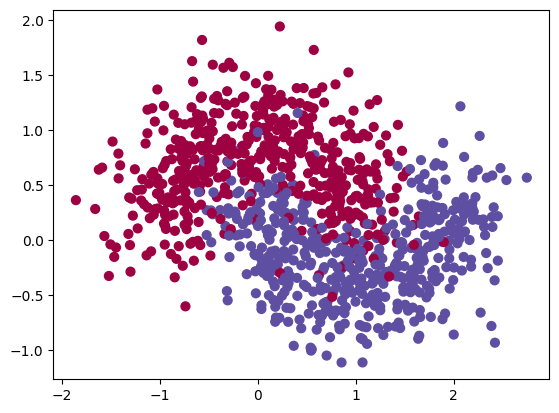

In [31]:
X_train_, Y_train_ = load_dataset()

In [32]:
X_train = X_train_[:, :900]
Y_train = Y_train_[: , :900]
X_test = X_train_[:, 900:]
Y_test = Y_train_[: , 900:]

print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(2, 900)
(1, 900)
(2, 100)
(1, 100)


Epoch: 0; Cost: 0.7697929504046799
Epoch: 500; Cost: 0.6024648119496699
Epoch: 1000; Cost: 0.40401897409023313
Epoch: 1500; Cost: 0.3386434419813322
Epoch: 2000; Cost: 0.322971166004274
Epoch: 2500; Cost: 0.31472656325189685
Epoch: 3000; Cost: 0.3092025286724537
Epoch: 3500; Cost: 0.30462476718882814
Epoch: 4000; Cost: 0.3005140721294497
Epoch: 4500; Cost: 0.29600447729006185
Epoch: 5000; Cost: 0.2901751236187977
Epoch: 5500; Cost: 0.28323743816097063
Epoch: 6000; Cost: 0.276605287016288
Epoch: 6500; Cost: 0.2698080229776888
Epoch: 7000; Cost: 0.2629827628467839
Epoch: 7500; Cost: 0.25621427246841594
Epoch: 8000; Cost: 0.24976519177635143
Epoch: 8500; Cost: 0.24295600282886834
Epoch: 9000; Cost: 0.23615491654888746
Epoch: 9500; Cost: 0.2294786473490499
Epoch: 10000; Cost: 0.2233427622524266
Epoch: 10500; Cost: 0.2177871086982447
Epoch: 11000; Cost: 0.21262900304673643
Epoch: 11500; Cost: 0.20786808501410056
Epoch: 12000; Cost: 0.20398358873795183
Epoch: 12500; Cost: 0.20087466952250566

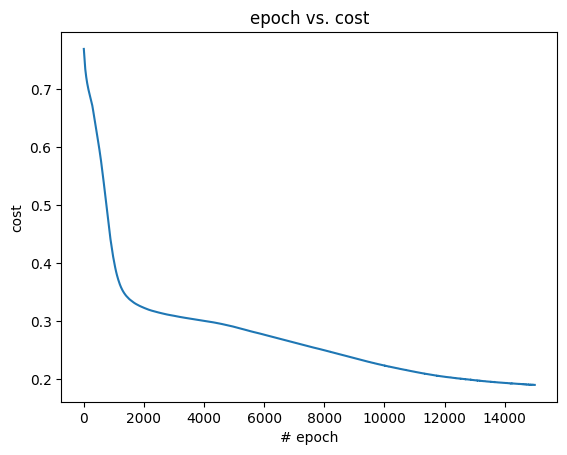

In [33]:
params = train(X_train, Y_train, X_test, Y_test, [10, 10, 6, 3], num_epochs=15000, learning_rate=3e-4, beta=0.9, mini_batch_size=64, epsilon=500, seed=1)

In [34]:
train_dataset = h5py.File("/home/samani/Documents/projects/deep-learning/data/train_cat.h5", "r")
train_set_x_orig = np.array(train_dataset["train_set_x"][:])
train_set_y_orig = np.array(train_dataset["train_set_y"][:])  

test_dataset = h5py.File("/home/samani/Documents/projects/deep-learning/data/test_cat.h5", "r")
test_set_x_orig = np.array(test_dataset["test_set_x"][:])  
test_set_y_orig = np.array(test_dataset["test_set_y"][:])  

classes = np.array(test_dataset["list_classes"][:])

train_set_y_orig = train_set_y_orig.reshape((1, train_set_y_orig.shape[0]))
test_set_y_orig = test_set_y_orig.reshape((1, test_set_y_orig.shape[0]))

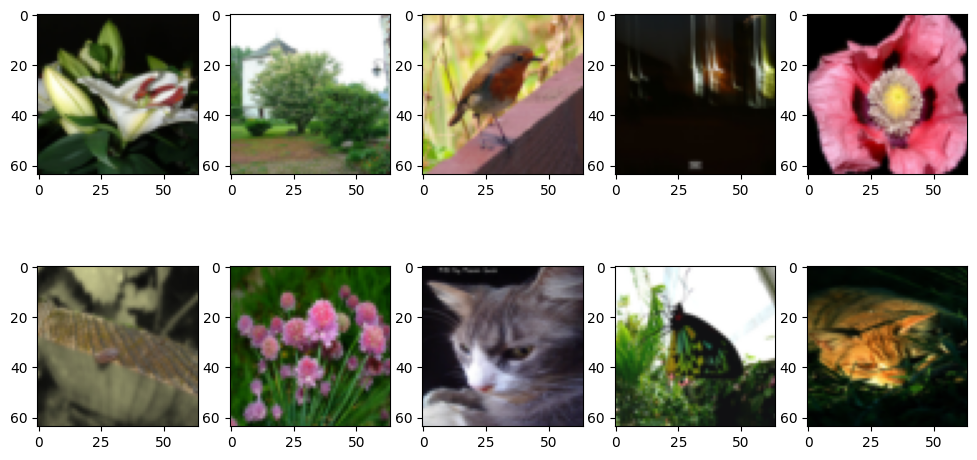

In [35]:
plt.figure(figsize=(12, 6))
plt.subplot(2, 5, 1)
plt.imshow(train_set_x_orig[4])
plt.subplot(2, 5, 2)
plt.imshow(train_set_x_orig[55])
plt.subplot(2, 5, 3)
plt.imshow(train_set_x_orig[10])
plt.subplot(2, 5, 4)
plt.imshow(train_set_x_orig[207])
plt.subplot(2, 5, 5)
plt.imshow(train_set_x_orig[140])
plt.subplot(2, 5, 6)
plt.imshow(train_set_x_orig[12])
plt.subplot(2, 5, 7)
plt.imshow(train_set_x_orig[21])
plt.subplot(2, 5, 8)
plt.imshow(train_set_x_orig[71])
plt.subplot(2, 5, 9)
plt.imshow(train_set_x_orig[16])
plt.subplot(2, 5, 10)
plt.imshow(train_set_x_orig[41])

plt.show()

In [36]:
train_set_x_flatten = train_set_x_orig.reshape(train_set_x_orig.shape[0], -1).T
test_set_x_flatten = test_set_x_orig.reshape(test_set_x_orig.shape[0], -1).T
print(train_set_x_flatten.shape)
print(test_set_x_flatten.shape)

(12288, 209)
(12288, 50)


In [37]:
X_train = train_set_x_flatten / 255
Y_train = train_set_y_orig
X_test = test_set_x_flatten / 255
Y_test = test_set_y_orig
print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(12288, 209)
(1, 209)
(12288, 50)
(1, 50)


Epoch: 0; Cost: 0.6814751880422404
Epoch: 500; Cost: 0.5246140178683865
Epoch: 1000; Cost: 0.4512292167433793
Epoch: 1500; Cost: 0.3859302432146555
Epoch: 2000; Cost: 0.322725471611391
Epoch: 2500; Cost: 0.26188409023716436
Train Accuracy: 0.9617224880382773
Test Accuracy: 0.74
Train Duration: 105.32847094535828


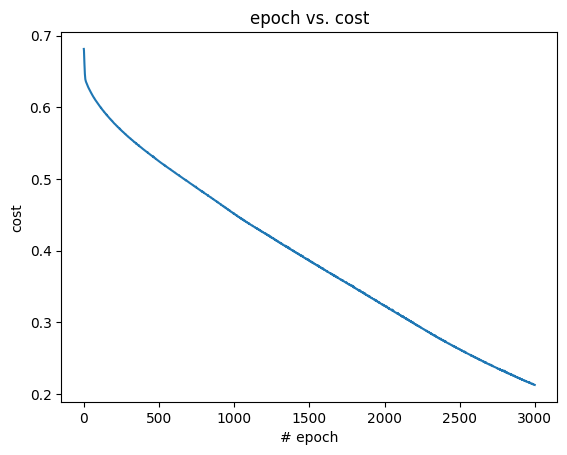

In [38]:
params = train(X_train, Y_train, X_test, Y_test, [10, 6], num_epochs=3000, learning_rate=1e-4, beta=0.9, mini_batch_size=32, epsilon=500, seed=1)